# 05 — Product Performance

**Project:** E-Commerce Customer & Revenue Analytics

**Business question this notebook contributes to:** which products are most valuable, and how concentrated is revenue among them?

**Purpose of this notebook:**

1. Build product-level performance metrics (revenue, quantity, orders, price)
2. Highest-revenue products
3. Highest-volume products — and how much that list differs from the revenue leaders
4. Revenue concentration across products (Pareto view)
5. Category-level view: revenue per category, and whether that revenue is spread across many products or concentrated in a few
6. Validation asserts
7. Save `product_performance.csv`
8. Summary of observations

**Input:** `data/processed/fact_sales_completed.csv` — same validated, Completed-only fact table used in `01`–`04`. `notebooks/02` already covered category-level revenue; this notebook drills down to the individual **product** level (50 products) that `02` didn't cover.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (10, 5)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED = ROOT / "data" / "processed"
FIGURES = ROOT / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

fact_sales = pd.read_csv(
    DATA_PROCESSED / "fact_sales_completed.csv",
    parse_dates=["order_date", "order_month", "signup_date"],
)
print("fact_sales_completed shape:", fact_sales.shape)
print("distinct products sold:", fact_sales["product_id"].nunique(), "(out of 50 total in products.csv)")

fact_sales_completed shape: (1625, 16)
distinct products sold: 50 (out of 50 total in products.csv)


## 1. Build product-level performance metrics

In [2]:
product_perf = fact_sales.groupby(["product_id", "product_name", "category"]).agg(
    revenue=("revenue", "sum"),
    quantity_sold=("quantity", "sum"),
    orders=("order_id", "nunique"),
    avg_price=("price", "mean"),
).reset_index()

product_perf["revenue_share_pct"] = (product_perf["revenue"] / product_perf["revenue"].sum() * 100).round(2)
product_perf["avg_price"] = product_perf["avg_price"].round(2)

print("Products scored:", len(product_perf))
product_perf.sort_values("revenue", ascending=False).head()

Products scored: 50


,product_id,product_name,category,revenue,quantity_sold,orders,avg_price,revenue_share_pct
15,16,Product_16,Makeup,9732,135,44,73.59,3.13
44,45,Product_45,Body,9644,154,44,64.37,3.10
24,25,Product_25,Hair,9527,131,38,73.58,3.06
22,23,Product_23,Body,9426,132,46,68.87,3.03
5,6,Product_6,Body,8661,132,40,65.32,2.78


## 2. Highest-revenue products

,product_name,category,revenue,revenue_share_pct,quantity_sold,orders
15,Product_16,Makeup,9732,3.13,135,44
44,Product_45,Body,9644,3.10,154,44
24,Product_25,Hair,9527,3.06,131,38
22,Product_23,Body,9426,3.03,132,46
5,Product_6,Body,8661,2.78,132,40
46,Product_47,Hair,8119,2.61,128,40
12,Product_13,Skin,8065,2.59,113,37
3,Product_4,Body,7788,2.50,120,37
31,Product_32,Body,7735,2.49,131,38
13,Product_14,Body,7474,2.40,100,34


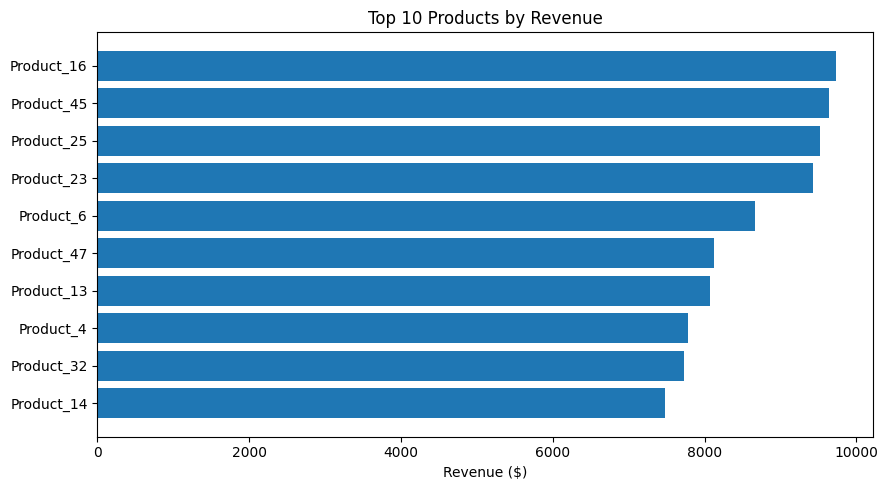

In [3]:
top_revenue = product_perf.sort_values("revenue", ascending=False).head(10)
display(top_revenue[["product_name", "category", "revenue", "revenue_share_pct", "quantity_sold", "orders"]])

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_revenue["product_name"][::-1], top_revenue["revenue"][::-1], color="#1f77b4")
ax.set_title("Top 10 Products by Revenue")
ax.set_xlabel("Revenue ($)")
fig.tight_layout()
fig.savefig(FIGURES / "12_top_products_revenue.png", dpi=150)
plt.show()

## 3. Highest-volume products

Ranked by units sold rather than dollars — a high-volume product isn't necessarily a high-revenue one if its price is low.

,product_name,category,quantity_sold,avg_price,revenue
44,Product_45,Body,154,64.37,9644
15,Product_16,Makeup,135,73.59,9732
5,Product_6,Body,132,65.32,8661
22,Product_23,Body,132,68.87,9426
31,Product_32,Body,131,60.95,7735
24,Product_25,Hair,131,73.58,9527
46,Product_47,Hair,128,64.20,8119
3,Product_4,Body,120,65.03,7788
41,Product_42,Skin,117,56.08,6655
25,Product_26,Makeup,115,61.69,7336


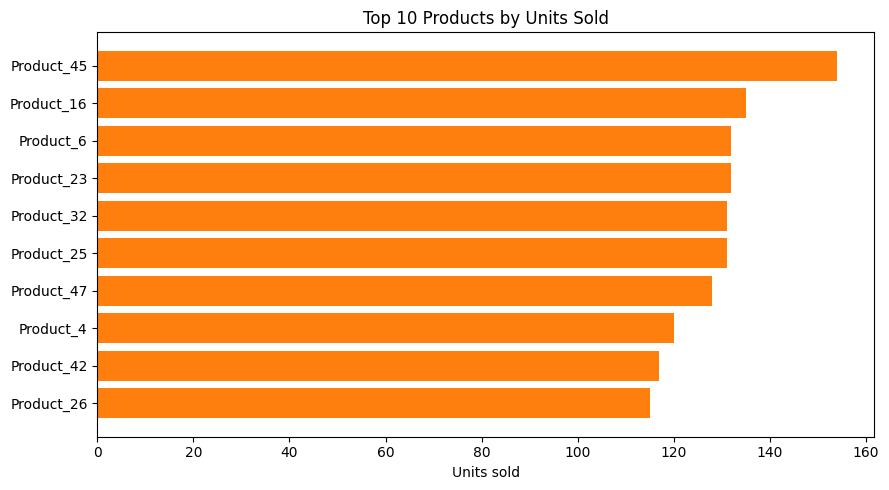

Products in BOTH top-10 lists (revenue and volume): 8 of 10


In [4]:
top_volume = product_perf.sort_values("quantity_sold", ascending=False).head(10)
display(top_volume[["product_name", "category", "quantity_sold", "avg_price", "revenue"]])

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_volume["product_name"][::-1], top_volume["quantity_sold"][::-1], color="#ff7f0e")
ax.set_title("Top 10 Products by Units Sold")
ax.set_xlabel("Units sold")
fig.tight_layout()
fig.savefig(FIGURES / "13_top_products_volume.png", dpi=150)
plt.show()

overlap = set(top_revenue["product_id"]) & set(top_volume["product_id"])
print(f"Products in BOTH top-10 lists (revenue and volume): {len(overlap)} of 10")

## 4. Revenue concentration across products (Pareto view)

Products ranked from highest to lowest revenue, with cumulative revenue share — the classic "what % of products drive what % of revenue" question.

Products needed to reach 80% of total revenue: 37 of 50 (74.0% of products)


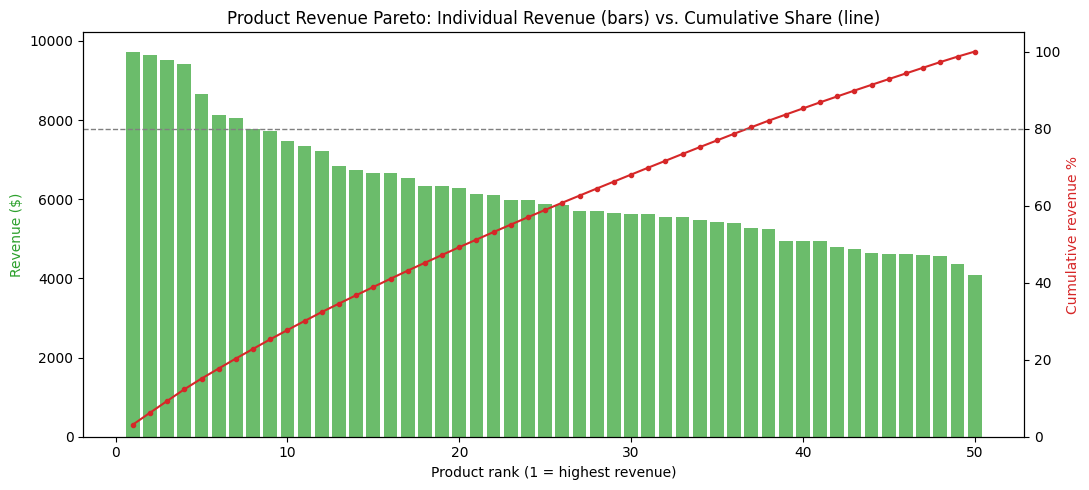

In [5]:
pareto = product_perf.sort_values("revenue", ascending=False).reset_index(drop=True)
pareto["product_rank"] = pareto.index + 1
pareto["pct_of_products"] = pareto["product_rank"] / len(pareto) * 100
pareto["cumulative_revenue_pct"] = pareto["revenue"].cumsum() / pareto["revenue"].sum() * 100

n_for_80pct = (pareto["cumulative_revenue_pct"] < 80).sum() + 1
print(f"Products needed to reach 80% of total revenue: {n_for_80pct} of {len(pareto)} "
      f"({n_for_80pct / len(pareto) * 100:.1f}% of products)")

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar(pareto["product_rank"], pareto["revenue"], color="#2ca02c", alpha=0.7)
ax1.set_xlabel("Product rank (1 = highest revenue)")
ax1.set_ylabel("Revenue ($)", color="#2ca02c")

ax2 = ax1.twinx()
ax2.plot(pareto["product_rank"], pareto["cumulative_revenue_pct"], color="#d62728", marker="o", markersize=3)
ax2.axhline(80, color="gray", linestyle="--", linewidth=1)
ax2.set_ylabel("Cumulative revenue %", color="#d62728")
ax2.set_ylim(0, 105)

ax1.set_title("Product Revenue Pareto: Individual Revenue (bars) vs. Cumulative Share (line)")
fig.tight_layout()
fig.savefig(FIGURES / "14_product_pareto.png", dpi=150)
plt.show()

## 5. Category view: revenue and how concentrated it is within each category

In [6]:
category_view = product_perf.groupby("category").agg(
    products=("product_id", "nunique"),
    revenue=("revenue", "sum"),
    top_product_revenue=("revenue", "max"),
).reset_index()

category_view["revenue_share_pct"] = (category_view["revenue"] / category_view["revenue"].sum() * 100).round(1)
category_view["avg_revenue_per_product"] = (category_view["revenue"] / category_view["products"]).round(2)
category_view["top_product_share_of_category_pct"] = (
    category_view["top_product_revenue"] / category_view["revenue"] * 100
).round(1)

category_view = category_view.sort_values("revenue", ascending=False)
display(category_view[[
    "category", "products", "revenue", "revenue_share_pct",
    "avg_revenue_per_product", "top_product_share_of_category_pct",
]])

,category,products,revenue,revenue_share_pct,avg_revenue_per_product,top_product_share_of_category_pct
1,Hair,17,101637,32.7,5978.65,9.4
2,Makeup,14,81085,26.1,5791.79,12.0
0,Body,10,76011,24.4,7601.10,12.7
3,Skin,9,52378,16.8,5819.78,15.4


## 6. Validation asserts

In [7]:
assert product_perf["product_id"].is_unique, "One row per product expected"
assert (product_perf["revenue"] >= 0).all(), "Revenue should never be negative"
assert (product_perf["quantity_sold"] > 0).all(), "Every product here should have at least one unit sold"
assert abs(product_perf["revenue_share_pct"].sum() - 100) < 0.1, "Revenue shares must sum to ~100%"
assert abs(product_perf["revenue"].sum() - fact_sales["revenue"].sum()) < 0.01, \
    "Sum of product revenue must equal total fact_sales_completed revenue"
assert n_for_80pct <= len(pareto), "80%-of-revenue product count can't exceed total product count"

print("All validation checks passed.")

All validation checks passed.


## 7. Save `product_performance.csv`

In [8]:
product_perf_out = product_perf.sort_values("revenue", ascending=False).reset_index(drop=True)
product_perf_out.to_csv(DATA_PROCESSED / "product_performance.csv", index=False)
print("Saved:", DATA_PROCESSED / "product_performance.csv", product_perf_out.shape)

Saved: /Users/yvonne/Desktop/E-commerce Analytics/data/processed/product_performance.csv (50, 8)


## 8. Summary of observations

- **There is no blockbuster product, and no dead inventory either.** All 50 products sold at least once. The top product by revenue (Product_16, Makeup) accounts for just 3.13% of total revenue, and the top 5 products together are only ~15% — revenue is spread remarkably evenly across the catalog rather than concentrated in a handful of stars.
- **The Pareto view confirms this quantitatively: it takes 37 of 50 products (74%) to reach 80% of revenue.** That's a far flatter distribution than the classic "20% of products drive 80% of revenue" pattern — this business doesn't have a small set of hero SKUs it's dependent on, which is a structurally low-risk position for the catalog (losing any single product wouldn't meaningfully dent revenue) but also means there isn't an obvious "double down on the winners" lever either.
- **Revenue and volume leaders mostly overlap (8 of the top 10 by each measure are the same products)** — pricing across the catalog is similar enough that units sold and dollars earned track closely together, rather than there being a distinct "cheap and high-volume" cluster separate from a "premium and low-volume" one.
- **At the category level, Body stands out on a per-product basis.** It has the fewest products (10, vs. Hair's 17) but the highest average revenue per product ($7,601 vs. Hair's $5,979) — Hair leads in total category revenue mainly by having more SKUs, not because its individual products outperform. Skin has the most concentrated category (its top product is 15.4% of category revenue, the highest of the four), but even that is a modest concentration, not a dominant single product.

`product_performance.csv` (50 products, sorted by revenue) is saved to `data/processed/` for reuse in Power BI and `reports/findings.md`.